# Supplementary Jiang24 UMAP coverage

Reproduces the Jiang24 UMAP coverage plot for control cells and pseudobulk conditions.


In [1]:
# Set to True to write image files to figures/supplement/output/.
SAVE_FIGURES = False

## UMAP coverage analysis


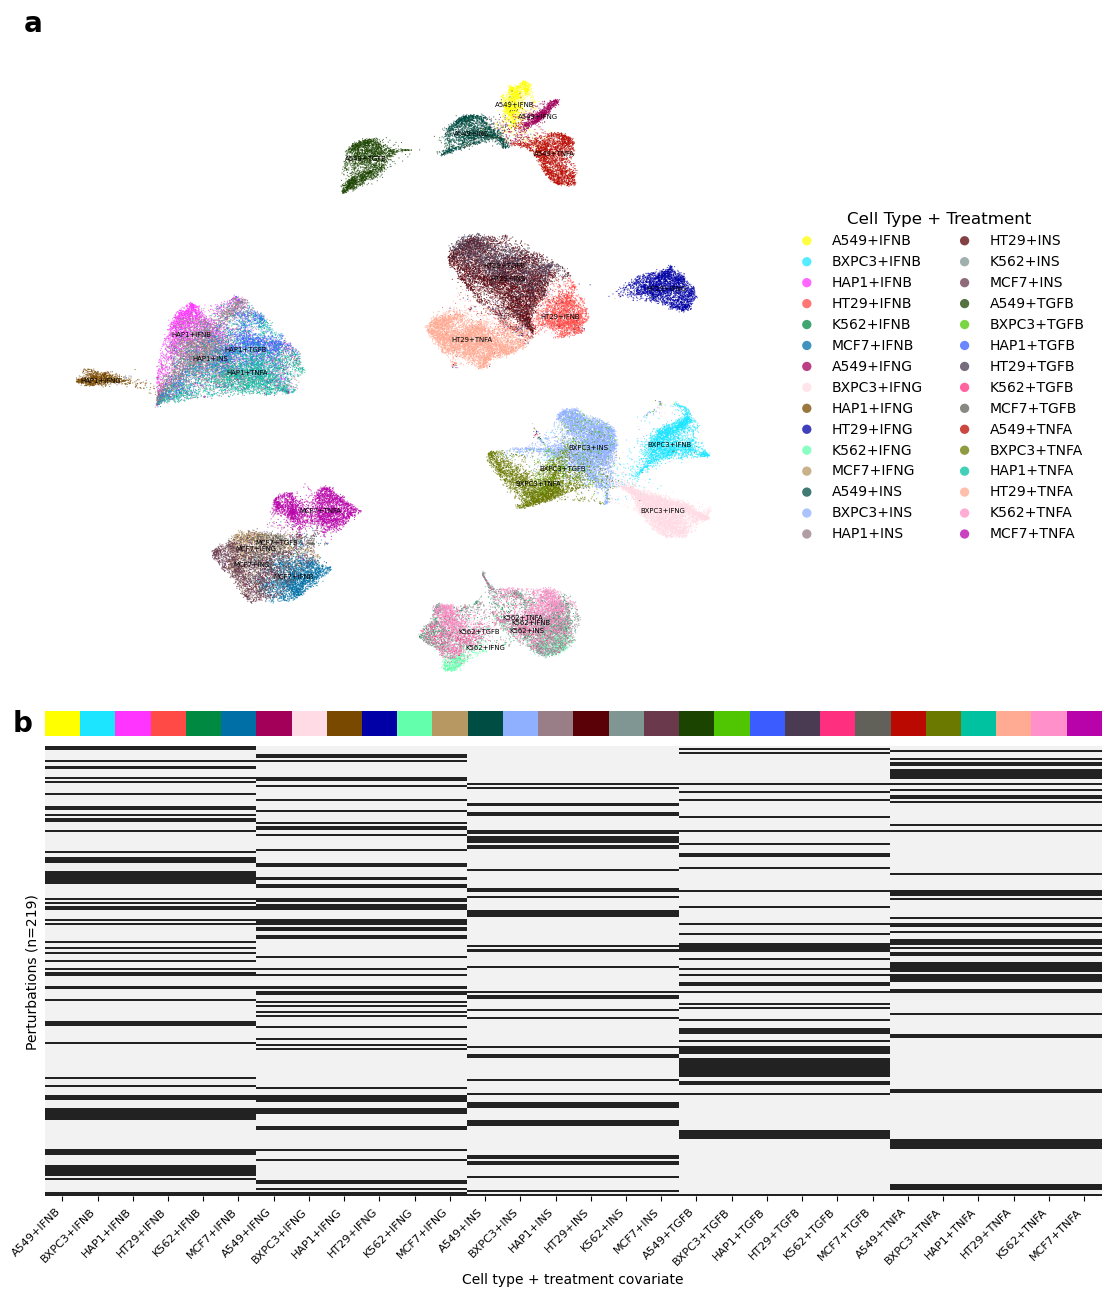

In [ ]:
import os
os.environ.setdefault("KMP_WARNINGS", "FALSE")
import importlib

import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import pdist


from pathlib import Path
ROOT = Path.cwd().resolve()
while not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()) and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if not ((ROOT / "transcouter").is_dir() and (ROOT / "code").is_dir() and (ROOT / "figures").is_dir()):
    raise RuntimeError("Run this notebook from inside the TranScouter repository")
os.chdir(ROOT)
Path("figures/main/output").mkdir(parents=True, exist_ok=True)
Path("figures/supplement/output").mkdir(parents=True, exist_ok=True)

########################################################
# Inline Settings
########################################################

N_NEIGHBORS = 15
N_PCS = 50
UMAP_MIN_DIST = 0.3
# UMAP_MIN_DIST = 0.1
# UMAP_MIN_DIST = 0.5
UMAP_SPREAD = 1.0

# PALETTE_NAME = "glasbey"
PALETTE_NAME = "scanpy"
# PALETTE_NAME = "tab20"
# PALETTE_NAME = "muted"
# PALETTE_NAME = "structured"

DOT_SIZE = 0.7
DOT_ALPHA = 0.75
SHOW_UMAP_TEXT_LABELS = True
UMAP_TEXT_FONTSIZE = 5

SHOW_HEATMAP_YLABELS = False
CLUSTER_PERTURBATION_ROWS = False

FIGSIZE = (11, 13)
FIG_DPI = 600
FIG_NAME = "supp_jiang.png"


########################################################
# Helper Functions
########################################################

def adjust_color(color, amount):
    rgb = np.array(color[:3])
    return tuple(1 - (1 - rgb) * amount)


def covariate_sort_key(covariate):
    cell_type, treatment = covariate.split("+")
    return treatment, cell_type


def get_palette(unique_covariates):
    if PALETTE_NAME == "glasbey":
        try:
            glasbey = importlib.import_module("glasbey")
            return dict(zip(unique_covariates, glasbey.create_palette(len(unique_covariates))))
        except ImportError:
            print("Install glasbey with `pip install glasbey`; falling back to Scanpy default_102.")
            palette = sc.pl.palettes.default_102
            return {cv: palette[i % len(palette)] for i, cv in enumerate(unique_covariates)}

    if PALETTE_NAME == "scanpy":
        palette = sc.pl.palettes.default_102
    elif PALETTE_NAME == "tab20":
        palette = plt.get_cmap("tab20").colors
    elif PALETTE_NAME == "muted":
        palette = [
            "#4E79A7", "#A0CBE8", "#F28E2B", "#FFBE7D", "#59A14F", "#8CD17D",
            "#B6992D", "#F1CE63", "#499894", "#86BCB6", "#E15759", "#FF9D9A",
            "#79706E", "#BAB0AC", "#D37295", "#FABFD2", "#B07AA1", "#D4A6C8",
            "#9D7660", "#D7B5A6", "#6B6ECF", "#B5B5E6", "#637939", "#CEDB9C",
            "#8C6D31", "#E7CB94", "#843C39", "#D6616B", "#7B4173", "#CE6DBD",
        ]
    elif PALETTE_NAME == "structured":
        cell_types = sorted({cv.split("+")[0] for cv in unique_covariates})
        treatments = sorted({cv.split("+")[1] for cv in unique_covariates})
        base_palette = plt.get_cmap("tab10").colors
        shade_levels = np.linspace(0.45, 1.0, len(treatments))
        color_map = {}
        for i, cell_type in enumerate(cell_types):
            base_color = base_palette[i % len(base_palette)]
            for treatment, shade in zip(treatments, shade_levels):
                color_map[f"{cell_type}+{treatment}"] = adjust_color(base_color, shade)
        return color_map
    else:
        raise ValueError(f"Unknown PALETTE_NAME: {PALETTE_NAME}")

    return {cv: palette[i % len(palette)] for i, cv in enumerate(unique_covariates)}


def clean_axis(ax):
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


########################################################
# Load Data
########################################################

if not os.path.exists("data/jiang/processed/jiang24_ctrl_for_umap.h5ad"):
    full_ad = sc.read_h5ad("data/jiang/raw/jiang24_processed.h5ad")
    ctrl_ad = full_ad[full_ad.obs["condition"] == "control"]
    ctrl_ad.obs["covariate"] = ctrl_ad.obs[["cell_type", "treatment"]].astype(str).agg("+".join, axis=1)
    sc.pp.highly_variable_genes(ctrl_ad, batch_key="covariate", flavor="seurat_v3", n_top_genes=5000)
    ctrl_ad = ctrl_ad[:, ctrl_ad.var.highly_variable]
    ctrl_ad.write_h5ad("data/jiang/processed/jiang24_ctrl_for_umap.h5ad")

umap_ad = sc.read_h5ad("data/jiang/processed/jiang24_ctrl_for_umap.h5ad")
if "covariate" not in umap_ad.obs:
    umap_ad.obs["covariate"] = umap_ad.obs[["cell_type", "treatment"]].astype(str).agg("+".join, axis=1)
umap_ad.obs["covariate"] = umap_ad.obs["covariate"].str.upper()

coverage_ad = sc.read_h5ad("data/jiang/processed/aggregate_sum_hvg.h5ad")
coverage_ad.obs["covariate"] = coverage_ad.obs["covariate"].str.upper()
coverage_ad.obs["perturbation"] = coverage_ad.obs["perturbation"].astype(str)
coverage_ad.obs["cov_pert"] = coverage_ad.obs[["covariate", "perturbation"]].agg("_".join, axis=1)


########################################################
# UMAP Coordinates
########################################################

sc.pp.scale(umap_ad)
sc.tl.pca(umap_ad, svd_solver="arpack")
sc.pp.neighbors(umap_ad, n_neighbors=N_NEIGHBORS, n_pcs=N_PCS)
sc.tl.umap(umap_ad, min_dist=UMAP_MIN_DIST, spread=UMAP_SPREAD)

umap = umap_ad.obsm["X_umap"]
umap_covariates = umap_ad.obs["covariate"].values


########################################################
# Perturbation Coverage Matrix
########################################################

heatmap_covariates = sorted(coverage_ad.obs["covariate"].unique(), key=covariate_sort_key)
perturbations = sorted(coverage_ad.obs["perturbation"].unique())
cov_perts = set(coverage_ad.obs["cov_pert"].values)

coverage_matrix = np.zeros((len(perturbations), len(heatmap_covariates)))
for i, pert in enumerate(perturbations):
    for j, cov in enumerate(heatmap_covariates):
        if f"{cov}_{pert}" in cov_perts:
            coverage_matrix[i, j] = 1

if CLUSTER_PERTURBATION_ROWS:
    row_dist = pdist(coverage_matrix, metric="hamming")
    row_linkage = linkage(row_dist, method="average")
    row_order = leaves_list(row_linkage)
    coverage_matrix = coverage_matrix[row_order]
    perturbations = [perturbations[i] for i in row_order]

all_covariates = sorted(
    set(heatmap_covariates).union(set(np.unique(umap_covariates))),
    key=covariate_sort_key,
)
covariate2color = get_palette(all_covariates)


########################################################
# Combined Figure
########################################################

fig = plt.figure(figsize=FIGSIZE, constrained_layout=True)
gs = fig.add_gridspec(
    nrows=4,
    ncols=2,
    height_ratios=[6.5, 0.25, 4.5, 0.15],
    width_ratios=[7.5, 3.5],
)

ax_umap = fig.add_subplot(gs[0, 0])
ax_legend = fig.add_subplot(gs[0, 1])
ax_strip = fig.add_subplot(gs[1, :])
ax_heatmap = fig.add_subplot(gs[2, :])

# A. UMAP
for cov in all_covariates:
    mask = umap_covariates == cov
    if not np.any(mask):
        continue
    ax_umap.scatter(
        umap[mask, 0],
        umap[mask, 1],
        s=DOT_SIZE,
        c=[covariate2color[cov]],
        label=cov,
        alpha=DOT_ALPHA,
        edgecolor="none",
        rasterized=True,
    )

if SHOW_UMAP_TEXT_LABELS:
    for cov in all_covariates:
        mask = umap_covariates == cov
        if not np.any(mask):
            continue
        median = np.median(umap[mask, :], axis=0)
        ax_umap.text(
            median[0],
            median[1],
            cov,
            fontsize=UMAP_TEXT_FONTSIZE,
            ha="center",
            va="center",
        )

clean_axis(ax_umap)
ax_umap.text(-0.03, 1.03, "a", transform=ax_umap.transAxes, fontsize=20, fontweight="bold")

ax_legend.axis("off")
handles, labels = ax_umap.get_legend_handles_labels()
legend = ax_legend.legend(
    handles,
    labels,
    title="Cell Type + Treatment",
    markerscale=8,
    fontsize=10,
    ncol=2,
    loc="center",
    borderaxespad=0.,
    frameon=False,
)
legend.get_title().set_fontsize(12)

# Covariate color strip, matching heatmap columns.
strip_colors = [covariate2color[cov] for cov in heatmap_covariates]
ax_strip.imshow(
    np.arange(len(heatmap_covariates)).reshape(1, -1),
    aspect="auto",
    cmap=ListedColormap(strip_colors),
    interpolation="nearest",
)
ax_strip.set_yticks([])
ax_strip.set_xticks([])
for spine in ax_strip.spines.values():
    spine.set_visible(False)
ax_strip.text(-0.03, 0.5, "b", transform=ax_strip.transAxes, fontsize=20, fontweight="bold", va="center")

# B. Perturbation coverage heatmap.
sns.heatmap(
    coverage_matrix,
    ax=ax_heatmap,
    cmap=["#F2F2F2", "#222222"],
    cbar=False,
    xticklabels=heatmap_covariates,
    yticklabels=perturbations if SHOW_HEATMAP_YLABELS else False,
    linewidths=0,
    rasterized=True,
)
ax_heatmap.set_xlabel("Cell type + treatment covariate")
ax_heatmap.set_ylabel(f"Perturbations (n={len(perturbations)})")
ax_heatmap.tick_params(axis="x", labelrotation=45, labelsize=8)
for label in ax_heatmap.get_xticklabels():
    label.set_horizontalalignment("right")
for spine in ax_heatmap.spines.values():
    spine.set_visible(False)

if globals().get("SAVE_FIGURES", False):
    plt.savefig(f"figures/supplement/output/{FIG_NAME}", dpi=FIG_DPI, bbox_inches="tight")

plt.show()